In [1]:
# Import and load saved model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

%matplotlib inline

project_root = os.path.dirname(os.getcwd())

model    = joblib.load(os.path.join(project_root, 'src', 'models', 'credit_risk_model.pkl'))
features = joblib.load(os.path.join(project_root, 'src', 'models', 'feature_columns.pkl'))

df = pd.read_csv(os.path.join(project_root, 'data', 'processed_credit_data.csv'))

print("Model and data loaded")
print(f"   Dataset shape: {df.shape}")

Model and data loaded
   Dataset shape: (1000, 61)


In [2]:
# Load data using the same shared pipeline
import sys, os
project_root = os.path.dirname(os.getcwd())
sys.path.insert(0, project_root)

from src.pipeline import load_raw_data, build_features
from sklearn.model_selection import train_test_split

raw      = load_raw_data()
X, y     = build_features(raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

saved_features = joblib.load(os.path.join(project_root, 'src', 'models', 'feature_columns.pkl'))
assert X.columns.tolist() == saved_features, "Column mismatch!"

y_prob = model.predict_proba(X_test)[:, 1]

print(f"Features match model perfectly")
print(f"   Test set: {len(y_test)} borrowers")
print(f"   Actual defaulters: {y_test.sum()}")

Features match model perfectly
   Test set: 200 borrowers
   Actual defaulters: 60


In [3]:
# Define a function to evaluate any threshold
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, confusion_matrix)

def evaluate_threshold(y_true, y_prob, threshold):
    """
    Converts probabilities to predictions using the given threshold,
    then computes all key metrics.
    """
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        'threshold':        threshold,
        'accuracy':         accuracy_score(y_true, y_pred),
        'precision':        precision_score(y_true, y_pred, zero_division=0),
        'recall':           recall_score(y_true, y_pred, zero_division=0),
        'f1':               f1_score(y_true, y_pred, zero_division=0),
        'true_positives':   tp,
        'false_positives':  fp,
        'false_negatives':  fn,
        'true_negatives':   tn,
        'missed_defaulters': fn,
        'defaulter_catch_rate': tp / (tp + fn) * 100
    }

In [5]:
# Run the A/B test: threshold 0.50 vs 0.35
result_050 = evaluate_threshold(y_test, y_prob, threshold=0.50)
result_035 = evaluate_threshold(y_test, y_prob, threshold=0.35)

comparison = pd.DataFrame([result_050, result_035]).set_index('threshold')

print("=" * 55)
print("       THRESHOLD A/B TEST RESULTS")
print("=" * 55)
print(comparison[[
    'accuracy', 'precision', 'recall', 'f1',
    'missed_defaulters', 'defaulter_catch_rate'
]].to_string())
print("=" * 55)

print("\nBUSINESS IMPACT SUMMARY")
print(f"\nThreshold 0.50:")
print(f"  Defaulters caught:  {result_050['true_positives']}")
print(f"  Defaulters missed:  {result_050['missed_defaulters']}  ← bad loans approved")
print(f"  Good borrowers wrongly rejected: {result_050['false_positives']}")

print(f"\nThreshold 0.35:")
print(f"  Defaulters caught:  {result_035['true_positives']}")
print(f"  Defaulters missed:  {result_035['missed_defaulters']}  ← bad loans approved")
print(f"  Good borrowers wrongly rejected: {result_035['false_positives']}")

missed_reduction = result_050['missed_defaulters'] - result_035['missed_defaulters']
missed_pct = missed_reduction / result_050['missed_defaulters'] * 100
print(f"\nSwitching to 0.35 catches {missed_reduction} more defaulters")
print(f"   ({missed_pct:.1f}% reduction in missed defaulters)")

       THRESHOLD A/B TEST RESULTS
           accuracy  precision  recall        f1  missed_defaulters  defaulter_catch_rate
threshold                                                                                
0.50          0.735   0.545455     0.7  0.613139                 18                  70.0
0.35          0.665   0.466019     0.8  0.588957                 12                  80.0

BUSINESS IMPACT SUMMARY

Threshold 0.50:
  Defaulters caught:  42
  Defaulters missed:  18  ← bad loans approved
  Good borrowers wrongly rejected: 35

Threshold 0.35:
  Defaulters caught:  48
  Defaulters missed:  12  ← bad loans approved
  Good borrowers wrongly rejected: 55

Switching to 0.35 catches 6 more defaulters
   (33.3% reduction in missed defaulters)


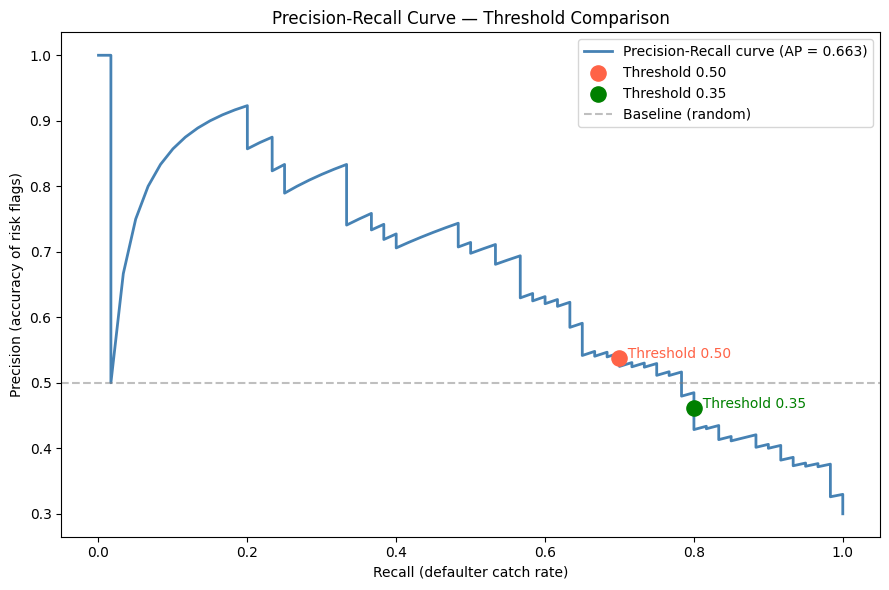

Chart saved to data/precision_recall_curve.png


In [6]:
# Precision-Recall curve
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

plt.figure(figsize=(9, 6))
plt.plot(recall_vals, precision_vals, color='steelblue', lw=2,
         label=f'Precision-Recall curve (AP = {avg_precision:.3f})')

for thresh, color, label in [(0.50, 'tomato', 'Threshold 0.50'),
                               (0.35, 'green',  'Threshold 0.35')]:
    idx = np.argmin(np.abs(pr_thresholds - thresh))
    plt.scatter(recall_vals[idx], precision_vals[idx],
                s=120, color=color, zorder=5, label=label)
    plt.annotate(f'  {label}',
                 (recall_vals[idx], precision_vals[idx]),
                 fontsize=10, color=color)

plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5,
            label='Baseline (random)')
plt.xlabel('Recall (defaulter catch rate)')
plt.ylabel('Precision (accuracy of risk flags)')
plt.title('Precision-Recall Curve — Threshold Comparison')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'data', 'precision_recall_curve.png'), dpi=150)
plt.show()
print("Chart saved to data/precision_recall_curve.png")

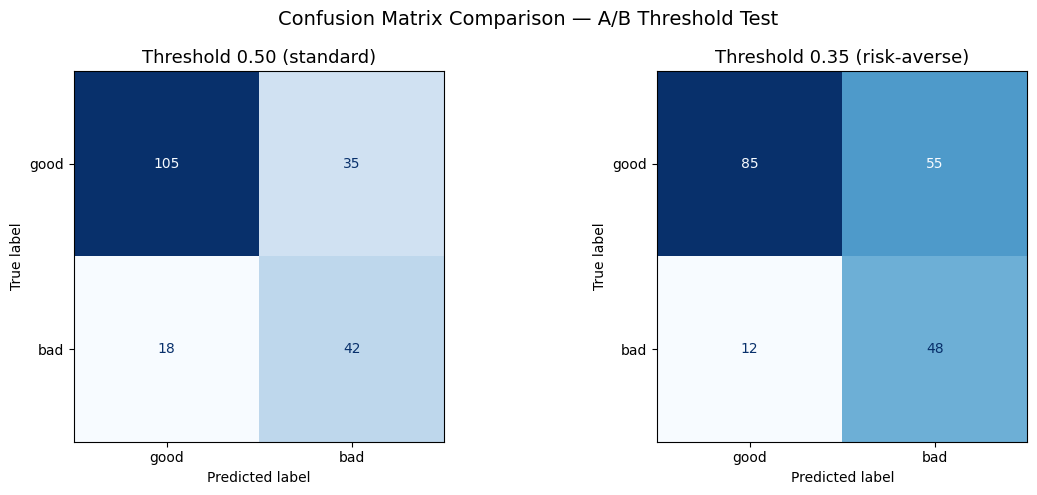

Chart saved to data/confusion_matrix_comparison.png


In [7]:
# Side by side confusion matrices
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, thresh, title in [
    (axes[0], 0.50, 'Threshold 0.50 (standard)'),
    (axes[1], 0.35, 'Threshold 0.35 (risk-averse)')
]:
    y_pred = (y_prob >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['good','bad'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title, fontsize=13)

plt.suptitle('Confusion Matrix Comparison — A/B Threshold Test', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'data', 'confusion_matrix_comparison.png'), dpi=150)
plt.show()
print("Chart saved to data/confusion_matrix_comparison.png")

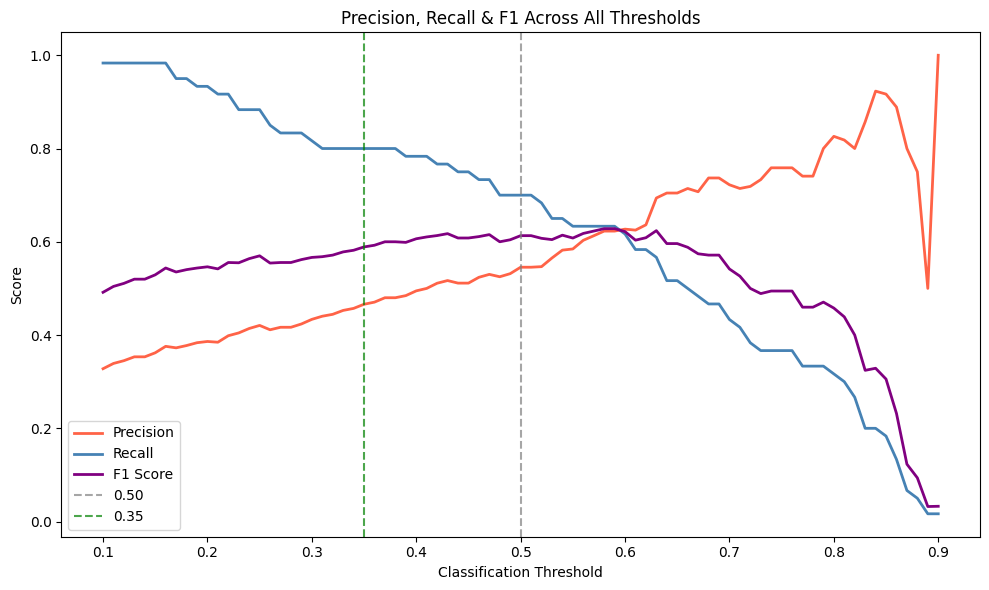

Chart saved to data/threshold_sweep.png


In [8]:
thresholds = np.arange(0.10, 0.91, 0.01)
results = [evaluate_threshold(y_test, y_prob, t) for t in thresholds]
sweep_df = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
plt.plot(sweep_df['threshold'], sweep_df['precision'],
         color='tomato',    lw=2, label='Precision')
plt.plot(sweep_df['threshold'], sweep_df['recall'],
         color='steelblue', lw=2, label='Recall')
plt.plot(sweep_df['threshold'], sweep_df['f1'],
         color='purple',    lw=2, label='F1 Score')

plt.axvline(x=0.50, color='gray',  linestyle='--', alpha=0.7, label='0.50')
plt.axvline(x=0.35, color='green', linestyle='--', alpha=0.7, label='0.35')

plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall & F1 Across All Thresholds')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'data', 'threshold_sweep.png'), dpi=150)
plt.show()
print("Chart saved to data/threshold_sweep.png")

In [9]:
report_lines = [
    "CREDITSENSE — THRESHOLD ANALYSIS REPORT",
    "=" * 50,
    "",
    "OBJECTIVE",
    "Determine the optimal classification threshold for",
    "a risk-averse lending strategy.",
    "",
    "A/B TEST RESULTS",
    f"Threshold 0.50 — Missed defaulters: {result_050['missed_defaulters']}",
    f"             — Defaulter catch rate: {result_050['defaulter_catch_rate']:.1f}%",
    f"             — False positives: {result_050['false_positives']}",
    "",
    f"Threshold 0.35 — Missed defaulters: {result_035['missed_defaulters']}",
    f"             — Defaulter catch rate: {result_035['defaulter_catch_rate']:.1f}%",
    f"             — False positives: {result_035['false_positives']}",
    "",
    "RECOMMENDATION",
    "Adopt threshold 0.35 for a risk-averse lending strategy.",
    f"This reduces missed defaulters by {missed_pct:.1f}%,",
    "accepting a moderate increase in false positives.",
    "The cost of a missed defaulter (bad loan approved)",
    "far outweighs the cost of a false positive",
    "(good borrower rejected — reapplication possible).",
]

report_path = os.path.join(project_root, 'data', 'threshold_report.txt')
with open(report_path, 'w') as f:
    f.write('\n'.join(report_lines))

print("Report saved to data/threshold_report.txt")

Report saved to data/threshold_report.txt


In [10]:
import subprocess

commands = [
    ['git', 'add', '.'],
    ['git', 'commit', '-m',
     'Phase 4: threshold A/B test, precision-recall analysis, risk strategy'],
    ['git', 'push']
]

for cmd in commands:
    result = subprocess.run(
        cmd, capture_output=True, text=True,
        cwd=project_root
    )
    print(result.stdout if result.stdout else result.stderr)


[main a22dcfc] Phase 4: threshold A/B test, precision-recall analysis, risk strategy
 18 files changed, 4404 insertions(+)
 create mode 100644 data/confusion_matrix_comparison.png
 create mode 100644 data/german_credit.csv
 create mode 100644 data/precision_recall_curve.png
 create mode 100644 data/processed_credit_data.csv
 create mode 100644 data/roc_curve_comparison.png
 create mode 100644 data/threshold_report.txt
 create mode 100644 data/threshold_sweep.png
 create mode 100644 notebooks/Untitled.ipynb
 create mode 100644 notebooks/credit_risk_modeling.ipynb
 create mode 100644 notebooks/src/models/credit_risk_model.pkl
 create mode 100644 notebooks/src/models/feature_columns.pkl
 create mode 100644 notebooks/threshold_analysis.ipynb
 create mode 100644 sql/explore.sql
 create mode 100644 src/load_data.py
 create mode 100644 src/models/credit_risk_model.pkl
 create mode 100644 src/models/feature_columns.pkl
 create mode 100644 src/pipeline.py

To https://github.com/DikshaGanchaudh